In [0]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer

In [0]:
file_location = '../data/raw/structured_traffic.csv'

df = pd.read_csv(file_location)

# Feature Engineering

## Modeling Objective

Predict hourly traffic volume for a given location and timestamp

In [0]:
df.head()

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume
0,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-09,1,1:00 AM,Monday,0,1,False,2012-01-09 01:00:00,20.0
1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-10,1,1:00 AM,Tuesday,1,1,False,2012-01-10 01:00:00,21.0
2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-11,1,1:00 AM,Wednesday,2,1,False,2012-01-11 01:00:00,27.0
3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-12,1,1:00 AM,Thursday,3,1,False,2012-01-12 01:00:00,22.0
4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,2012-01-13,1,1:00 AM,Friday,4,1,False,2012-01-13 01:00:00,31.0


In [0]:
y = df.traffic_volume

## Creating Cyclical Encoding for Time Variables

Linear regression assumes linear relationships between predictors and the response; however, time periods are periodic, not linear. 

These variables allow model to approximate periodic functions and fit them into model with a cyclical/wave pattern so that hours such as 11pm (23) and 12am (0) are treated as similar/close, rather than far apart dissimilar.

### Hour, Day of Week, and Month

In [0]:
df = df.assign(
  hour_sin = lambda x: np.sin(2 * np.pi * x.hour / 24),
  hour_cos = lambda x: np.cos( 2 * np.pi * x.hour / 24),
  dow_sin = lambda x: np.sin(2 * np.pi * x.weekday / 7),
  dow_cos = lambda x: np.cos(2 * np.pi * df.weekday / 7),
  month_sin = lambda x: np.sin(2 * np.pi * x.month / 12),
  month_cos = lambda x: np.cos(2 * np.pi * x.month / 12)
)

## Creating Lag Features and Rolling Average Variables to Capture Recent Traffic Behavior

In [0]:
df.sort_values(['segment_id', 'timestamp']).head(10)

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
996039,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,0,12:00 AM,Saturday,5,10,True,2014-10-11,504.0,0.000000,1.000000e+00,-0.974928,-0.222521,-0.866025,0.5
12651,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,1,1:00 AM,Saturday,5,10,True,2014-10-11 01:00:00,305.0,0.258819,9.659258e-01,-0.974928,-0.222521,-0.866025,0.5
55407,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,2,2:00 AM,Saturday,5,10,True,2014-10-11 02:00:00,222.0,0.500000,8.660254e-01,-0.974928,-0.222521,-0.866025,0.5
98163,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,3,3:00 AM,Saturday,5,10,True,2014-10-11 03:00:00,137.0,0.707107,7.071068e-01,-0.974928,-0.222521,-0.866025,0.5
140919,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,4,4:00 AM,Saturday,5,10,True,2014-10-11 04:00:00,138.0,0.866025,5.000000e-01,-0.974928,-0.222521,-0.866025,0.5
183675,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,5,5:00 AM,Saturday,5,10,True,2014-10-11 05:00:00,114.0,0.965926,2.588190e-01,-0.974928,-0.222521,-0.866025,0.5
226431,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,6,6:00 AM,Saturday,5,10,True,2014-10-11 06:00:00,155.0,1.000000,6.123234e-17,-0.974928,-0.222521,-0.866025,0.5
269187,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,7,7:00 AM,Saturday,5,10,True,2014-10-11 07:00:00,283.0,0.965926,-2.588190e-01,-0.974928,-0.222521,-0.866025,0.5
311943,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,8,8:00 AM,Saturday,5,10,True,2014-10-11 08:00:00,355.0,0.866025,-5.000000e-01,-0.974928,-0.222521,-0.866025,0.5
354699,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,9,9:00 AM,Saturday,5,10,True,2014-10-11 09:00:00,485.0,0.707107,-7.071068e-01,-0.974928,-0.222521,-0.866025,0.5


In [0]:
df.sort_values(['segment_id', 'timestamp']).tail(10)

,segment_id,roadway__name,from,to,direction,date,hour,hour_start,day_of_week,weekday,month,is_weekend,timestamp,traffic_volume,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
589081,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,14,2:00 PM,Sunday,6,10,True,2019-10-13 14:00:00,835.0,-0.500000,-8.660254e-01,-0.781831,0.62349,-0.866025,0.5
631837,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,15,3:00 PM,Sunday,6,10,True,2019-10-13 15:00:00,777.0,-0.707107,-7.071068e-01,-0.781831,0.62349,-0.866025,0.5
674593,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,16,4:00 PM,Sunday,6,10,True,2019-10-13 16:00:00,684.0,-0.866025,-5.000000e-01,-0.781831,0.62349,-0.866025,0.5
717349,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,17,5:00 PM,Sunday,6,10,True,2019-10-13 17:00:00,721.0,-0.965926,-2.588190e-01,-0.781831,0.62349,-0.866025,0.5
760105,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,18,6:00 PM,Sunday,6,10,True,2019-10-13 18:00:00,697.0,-1.000000,-1.836970e-16,-0.781831,0.62349,-0.866025,0.5
802861,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,19,7:00 PM,Sunday,6,10,True,2019-10-13 19:00:00,724.0,-0.965926,2.588190e-01,-0.781831,0.62349,-0.866025,0.5
845617,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,20,8:00 PM,Sunday,6,10,True,2019-10-13 20:00:00,571.0,-0.866025,5.000000e-01,-0.781831,0.62349,-0.866025,0.5
888373,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,21,9:00 PM,Sunday,6,10,True,2019-10-13 21:00:00,445.0,-0.707107,7.071068e-01,-0.781831,0.62349,-0.866025,0.5
931129,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,22,10:00 PM,Sunday,6,10,True,2019-10-13 22:00:00,448.0,-0.500000,8.660254e-01,-0.781831,0.62349,-0.866025,0.5
973885,9017050,Columbus Avenue,Dead end,Dead end,SB,2019-10-13,23,11:00 PM,Sunday,6,10,True,2019-10-13 23:00:00,527.0,-0.258819,9.659258e-01,-0.781831,0.62349,-0.866025,0.5


In [0]:
df = df.sort_values(['segment_id', 'timestamp'])

In [0]:
df = df.assign(
    lag_1h = lambda x: x.groupby('segment_id').traffic_volume.shift(1), # last hour traffic
    lag_24h = lambda x: x.groupby('segment_id').traffic_volume.shift(24), # traffic same hour yesterday
    lag_168h = lambda x: x.groupby('segment_id').traffic_volume.shift(168) # traffic same hour last week

)

## Best Predictive Elastic Net Model

### Removing Features for Modeling

These features are redundant and create unnecessary noise for (what should be) best predictive linear model.

In [0]:
X = df.drop(
    columns = ['date', # already extracted necessary components
               'hour_start', # string representation of hour
               'day_of_week', # duplicates info
               'hour',
               'weekday',
               'month', # have cyclical variables
               'roadway__name',
               'from',
               'to' # these have thousands of unique values and would explode dummy variables + redundant with segment_id
               ]
)

### Train Test Split

This is is time series data essentially, so shouldn't (can't) randomly split. 

Would cause data leakage if randomly split ('future' traffic patterns may be used as training).

For this series -> Train on earlier periods, tune on later preiods, and evaluate on most recent periods

#### Converting boolean is_weekend feature to numeric true binary feature

In [0]:
X = X.assign(
    is_weekend = lambda x: np.where(x.is_weekend==True, 1, 0)
)

#### Dropping Rows with missing lag values and response variables

Shouldn't impute. Not a good idea to introduce so much fake historical traffic data to get a dependable model.

Will still have plenty of training and test data even after dropping.

Don't want any rows with null values

In [0]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026144 entries, 996039 to 973885
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   segment_id      1026144 non-null  int64  
 1   direction       1026144 non-null  object 
 2   is_weekend      1026144 non-null  int64  
 3   timestamp       1026144 non-null  object 
 4   traffic_volume  1023064 non-null  float64
 5   hour_sin        1026144 non-null  float64
 6   hour_cos        1026144 non-null  float64
 7   dow_sin         1026144 non-null  float64
 8   dow_cos         1026144 non-null  float64
 9   month_sin       1026144 non-null  float64
 10  month_cos       1026144 non-null  float64
 11  lag_1h          1021179 non-null  float64
 12  lag_24h         977512 non-null   float64
 13  lag_168h        698272 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 117.4+ MB


In [0]:
X = X.dropna(subset=['traffic_volume','lag_1h', 'lag_24h', 'lag_168h'])

#### Considering Sensor Anomaly Filtering

In [0]:
X.traffic_volume.describe()

count    693804.000000
mean        358.894136
std         464.735262
min           0.000000
25%          98.000000
50%         235.000000
75%         441.000000
max        9211.000000
Name: traffic_volume, dtype: float64

In [0]:
X.traffic_volume.nlargest(20)

829296    9211.0
786390    9017.0
786540    8981.0
743784    8088.0
829146    8026.0
743634    7203.0
701028    6727.0
871902    6659.0
700878    6515.0
658272    6488.0
829298    6427.0
658274    6421.0
786542    6419.0
615366    6404.0
615516    6227.0
708603    6222.0
708661    6221.0
623149    6216.0
733583    6169.0
743786    6163.0
Name: traffic_volume, dtype: float64

In [0]:
X.loc[X.traffic_volume.nlargest(20).index]

,segment_id,direction,is_weekend,timestamp,traffic_volume,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1h,lag_24h,lag_168h
829296,139303,SB,1,2015-09-20 20:00:00,9211.0,-0.866025,5.000000e-01,-0.781831,0.623490,-1.000000,-1.836970e-16,8981.0,8026.0,10532.0
786390,139303,SB,1,2015-09-19 19:00:00,9017.0,-0.965926,2.588190e-01,-0.974928,-0.222521,-1.000000,-1.836970e-16,7203.0,6377.0,8326.0
786540,139303,SB,1,2015-09-20 19:00:00,8981.0,-0.965926,2.588190e-01,-0.781831,0.623490,-1.000000,-1.836970e-16,8088.0,9017.0,9879.0
743784,139303,SB,1,2015-09-20 18:00:00,8088.0,-1.000000,-1.836970e-16,-0.781831,0.623490,-1.000000,-1.836970e-16,6727.0,7203.0,9762.0
829146,139303,SB,1,2015-09-19 20:00:00,8026.0,-0.866025,5.000000e-01,-0.974928,-0.222521,-1.000000,-1.836970e-16,9017.0,6955.0,7519.0
743634,139303,SB,1,2015-09-19 18:00:00,7203.0,-1.000000,-1.836970e-16,-0.974928,-0.222521,-1.000000,-1.836970e-16,6515.0,6350.0,6996.0
701028,139303,SB,1,2015-09-20 17:00:00,6727.0,-0.965926,-2.588190e-01,-0.781831,0.623490,-1.000000,-1.836970e-16,6488.0,6515.0,6393.0
871902,139303,SB,1,2015-09-19 21:00:00,6659.0,-0.707107,7.071068e-01,-0.974928,-0.222521,-1.000000,-1.836970e-16,8026.0,4634.0,6569.0
700878,139303,SB,1,2015-09-19 17:00:00,6515.0,-0.965926,-2.588190e-01,-0.974928,-0.222521,-1.000000,-1.836970e-16,5338.0,6379.0,7312.0
658272,139303,SB,1,2015-09-20 16:00:00,6488.0,-0.866025,-5.000000e-01,-0.781831,0.623490,-1.000000,-1.836970e-16,6227.0,5338.0,6771.0


Not safe to remove. Likely evening and afternoon peak hours. Appears to be real traffic behavior rather than sensor glitches.

#### Temporal Based Train Test Split

In [0]:
train = X.loc[X.timestamp <= "2019-12-01"]

test = X.loc[X.timestamp > "2019-12-01"]

In [0]:
print(len(train))
print(len(test))


555948
137856


### Removing timestamp (only needed for splitting at this point)

In [0]:
train.drop(columns = 'timestamp', inplace = True)
test.drop(columns='timestamp', inplace=True)

/home/spark-254b2a4f-5d9e-4c8a-88a0-30/.ipykernel/2640/command-4904139875950174-554061747:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(columns = 'timestamp', inplace = True)
/home/spark-254b2a4f-5d9e-4c8a-88a0-30/.ipykernel/2640/command-4904139875950174-554061747:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns='timestamp', inplace=True)


In [0]:
train = train.reset_index(drop=True)

In [0]:
test = test.reset_index(drop=True)

In [0]:
train_X = train[[c for c in train.columns if c != "traffic_volume"]]
train_y = train.traffic_volume

In [0]:
test_X = test[[c for c in test.columns if c != "traffic_volume"]]
test_y = test.traffic_volume

In [0]:
train_X.head() # predictor features

,segment_id,direction,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1h,lag_24h,lag_168h
0,646,NB,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0.5,0.866025,239.0,0.0,53.0
1,646,SB,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0.5,0.866025,232.0,0.0,37.0
2,646,NB,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.5,0.866025,241.0,37.0,13.0
3,646,SB,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.5,0.866025,262.0,47.0,19.0
4,646,NB,0,-5.000000e-01,-0.866025,-0.433884,-0.900969,0.5,0.866025,272.0,28.0,10.0


In [0]:
test_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137856 entries, 0 to 137855
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   segment_id  137856 non-null  int64  
 1   direction   137856 non-null  object 
 2   is_weekend  137856 non-null  int64  
 3   hour_sin    137856 non-null  float64
 4   hour_cos    137856 non-null  float64
 5   dow_sin     137856 non-null  float64
 6   dow_cos     137856 non-null  float64
 7   month_sin   137856 non-null  float64
 8   month_cos   137856 non-null  float64
 9   lag_1h      137856 non-null  float64
 10  lag_24h     137856 non-null  float64
 11  lag_168h    137856 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 12.6+ MB


In [0]:
train_y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 555948 entries, 0 to 555947
Series name: traffic_volume
Non-Null Count   Dtype  
--------------   -----  
555948 non-null  float64
dtypes: float64(1)
memory usage: 4.2 MB


### Building Preprocessing Pipeline for Scaling Numeric Features (Sin and Cos Features Already Naturally Normalized) and Creating Dummy Variables for Categorical Features (Avoid Data Leakage)

In [0]:
train_X.head()

,segment_id,direction,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1h,lag_24h,lag_168h
0,646,NB,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0.5,0.866025,239.0,0.0,53.0
1,646,SB,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0.5,0.866025,232.0,0.0,37.0
2,646,NB,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.5,0.866025,241.0,37.0,13.0
3,646,SB,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0.5,0.866025,262.0,47.0,19.0
4,646,NB,0,-5.000000e-01,-0.866025,-0.433884,-0.900969,0.5,0.866025,272.0,28.0,10.0


In [0]:
categorical_features = ['segment_id', 'direction']
numeric_features = ['lag_1h', 'lag_24h', 'lag_168h']

numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
  ('num', numeric_transformer, numeric_features),
  ('cat', categorical_transformer, categorical_features)
], remainder='passthrough') # bypasses normalization of features (cyclical and binary) since they are already scaled naturally

In [0]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=10000, tol=1e-3))
])

### Parameter Grid (Search space) for ElasticNet

Hyperparameters for tuning:
 - alpha = overall regularization strength
 - l1_ratio = blended proportion of l1 (lasso) and l2 (ridge) penalty to apply
   - if 1, full lasso
   - if 0, full ridge

In [0]:
param_grid = {
  'model__alpha': [0.01, 0.1, 1, 10],
  'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

### Cross Validation for the Training Set

In [0]:
tscv = TimeSeriesSplit(n_splits=5)

### Instantiating Grid Search Cross Cross-Validation Object for Training and Assessment

In [0]:
grid = GridSearchCV(
  estimator=pipeline,
  param_grid=param_grid,
  cv=tscv,
  scoring='neg_root_mean_squared_error',
  n_jobs=-1 # uses all CPU cores (speeds up training)
)

### Model Training and Assessment of Folds

In [0]:
grid.fit(train_X, train_y)

/databricks/python/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['lag_1h',
                                                                          'lag_24h',
                                                                          'lag_168h']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['segment_id',
                                                                          'direction'])])),
                                       ('model',
                                        ElasticNet(max_iter=10000,
                                                   tol=0.001))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.01, 0.1, 1, 10],
                         'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='neg_root_mean_squared_error')

#### Best hyperparameter setting and best CV RMSE score

In [0]:
best_model = grid.best_estimator_

In [0]:
print(f'Best hyperparameters: {grid.best_params_}')
print(f'Best CV RMSE: {-grid.best_score_}')

Best hyperparameters: {'model__alpha': 0.1, 'model__l1_ratio': 0.7}
Best CV RMSE: 204.50958073647834


- alpha=0.1 -> moderate regularization strength
- l1_ratio=0.7 -> mostly lasso with some ridge

Somewhat sparse model with some ridge stability is optimal

In [0]:
train_y.describe()

count    555948.000000
mean        381.505725
std         499.565478
min           0.000000
25%         104.000000
50%         245.000000
75%         462.000000
max        9211.000000
Name: traffic_volume, dtype: float64

#### Recovering the Coefficients and Feature Names

In [0]:
elastic = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

In [0]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": elastic.coef_,
})

# cleaner feature labels
coef_df['feature'] = (
    coef_df['feature'].str.replace('num__',"", regex=False).str.replace(
        'cat__',"", regex=False).str.replace('remainder__',"", regex=False)
    )


coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

intercept = elastic.intercept_

# Most influential coefficients
print(f'Intercept: {intercept}')
coef_df.head(20)

Intercept: 379.15681468191826


,feature,coefficient,abs_coefficient
0,lag_1h,253.134517,253.134517
1,lag_24h,133.039400,133.039400
1878,hour_cos,-92.394115,92.394115
2,lag_168h,88.072122,88.072122
1877,hour_sin,-84.300117,84.300117
1870,direction_SB-MAIN,20.819642,20.819642
1871,direction_SB-SER,-19.535520,19.535520
1866,direction_NB-MAIN,18.178957,18.178957
1867,direction_NB-SER,-15.837402,15.837402
1876,is_weekend,-7.417915,7.417915


In [0]:
# top positive coefficients
coef_df.sort_values('coefficient', ascending=False).head(10)

,feature,coefficient,abs_coefficient
0,lag_1h,253.134517,253.134517
1,lag_24h,133.039400,133.039400
2,lag_168h,88.072122,88.072122
1870,direction_SB-MAIN,20.819642,20.819642
1866,direction_NB-MAIN,18.178957,18.178957
1700,segment_id_251949,6.658098,6.658098
1879,dow_sin,4.172448,4.172448
1873,direction_WB-MR,4.001684,4.001684
1864,direction_NB,3.175163,3.175163
1413,segment_id_154454,2.445095,2.445095


In [0]:
# top negative coefficients
coef_df.sort_values('coefficient', ascending=True).head()

,feature,coefficient,abs_coefficient
1878,hour_cos,-92.394115,92.394115
1877,hour_sin,-84.300117,84.300117
1871,direction_SB-SER,-19.535520,19.535520
1867,direction_NB-SER,-15.837402,15.837402
1876,is_weekend,-7.417915,7.417915


### Evaluating Model Performance

In [0]:
# predictions
train_pred = best_model.predict(train_X)
test_pred = best_model.predict(test_X)

In [0]:
# metric function
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def regression_metrics(y_true, y_pred, n_features):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # avoid division-by-zero flags in MAPE
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2,
        'Adjusted R2': adj_r2
    }

In [0]:
# number of fitted predictors after fitting
n_features = len(feature_names)
print(f'Number of kept features in model: {n_features}')

Number of kept features in model: 1883


#### Training Metrics

In [0]:
train_metrics = regression_metrics(train_y, train_pred, n_features)
train_metrics

{'RMSE': np.float64(191.82530273015414),
 'MAE': 109.04886694129945,
 'MAPE (%)': np.float64(93.78243335734554),
 'R2': 0.852555788394995,
 'Adjusted R2': 0.8520546956503803}

#### Test Metrics

In [0]:
test_metrics = regression_metrics(test_y, test_pred, n_features)
test_metrics

{'RMSE': np.float64(124.3925328404315),
 'MAE': 84.03208199168199,
 'MAPE (%)': np.float64(110.50137715493813),
 'R2': 0.7794303141382426,
 'Adjusted R2': 0.7763757682135104}

#### Model Evaluation Tables

In [0]:
# train vs test metrics table

metrics_df = pd.DataFrame([
    {'dataset': 'train', **train_metrics},
    {'dataset': 'test', **test_metrics}
])

metrics_df

,dataset,RMSE,MAE,MAPE (%),R2,Adjusted R2
0,train,191.825303,109.048867,93.782433,0.852556,0.852055
1,test,124.392533,84.032082,110.501377,0.779430,0.776376


In [0]:
# Cross-validation performance table

cv_results_df = pd.DataFrame(grid.cv_results_)

cv_summary = cv_results_df[[
    'param_model__alpha',
    'param_model__l1_ratio',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].copy()

cv_summary['CV_RMSE'] = -cv_summary['mean_test_score']
cv_summary['CV_RMSE_std'] = cv_summary['std_test_score']

cv_summary = cv_summary.drop(columns=['mean_test_score', 'std_test_score'])
cv_summary = cv_summary.sort_values('rank_test_score')

cv_summary.head(10)

,param_model__alpha,param_model__l1_ratio,rank_test_score,CV_RMSE,CV_RMSE_std
8,0.10,0.7,1,204.509581,36.395783
7,0.10,0.5,2,204.760135,35.922811
9,0.10,0.9,3,205.060128,36.196953
6,0.10,0.3,4,205.298745,35.407920
5,0.10,0.1,5,206.034268,34.928666
0,0.01,0.1,6,206.103076,35.154615
14,1.00,0.9,7,206.405969,35.161557
1,0.01,0.3,8,206.634915,34.647750
2,0.01,0.5,9,207.526031,33.823274
3,0.01,0.7,10,209.302425,32.385326


In [0]:
# split-by-split cv scores
split_cols = [c for c in cv_results_df.columns if c.startswith("split") and c.endswith("_test_score")]

cv_splits = cv_results_df[
    ["param_model__alpha", "param_model__l1_ratio"] + split_cols
].copy()

cv_splits[split_cols] = -cv_splits[split_cols]
cv_splits

,param_model__alpha,param_model__l1_ratio,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,0.01,0.1,173.320463,253.854028,165.731158,197.926422,239.683311
1,0.01,0.3,176.056195,254.024716,165.742940,197.946356,239.404367
2,0.01,0.5,180.632846,254.152738,165.776792,198.071347,238.996430
3,0.01,0.7,189.582597,254.182669,165.884844,198.566586,238.295426
4,0.01,0.9,214.345617,253.922707,166.604001,202.243786,236.748405
5,0.10,0.1,168.818527,247.101444,166.719336,203.101548,244.430488
6,0.10,0.3,167.335622,248.418371,166.359810,201.199056,243.180866
7,0.10,0.5,166.163265,249.996623,166.052961,199.536276,242.051551
8,0.10,0.7,165.683268,251.887107,165.814659,198.139260,241.023610
9,0.10,0.9,168.802968,254.157219,165.673164,196.859409,239.807882


### Interpretability Plots

#### Predicted vs Actual Scatter Plot

In [0]:
import matplotlib.pyplot as plt

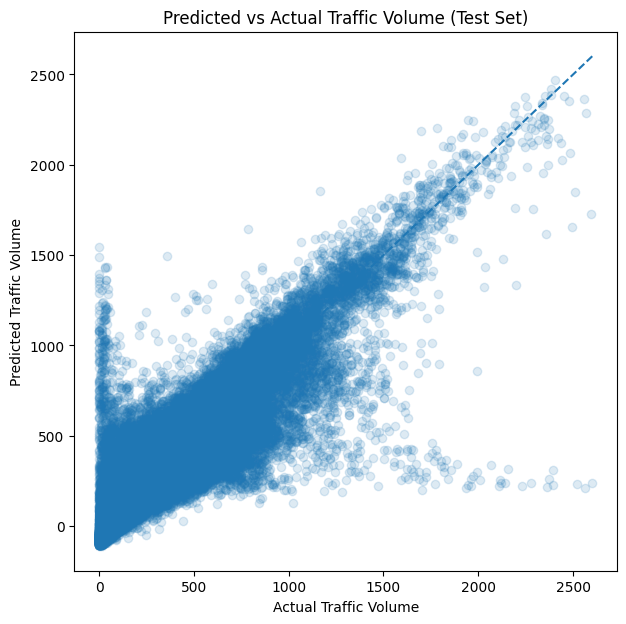

In [0]:
plt.figure(figsize=(7,7))
plt.scatter(test_y, test_pred, alpha=0.15)
plt.plot(
    [test_y.min(), test_y.max()],
    [test_y.min(), test_y.max()],
    linestyle="--"
)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Predicted vs Actual Traffic Volume (Test Set)")
plt.show()

Can see model has an issue detecting large spikes in traffic volume

#### Residual Histogram

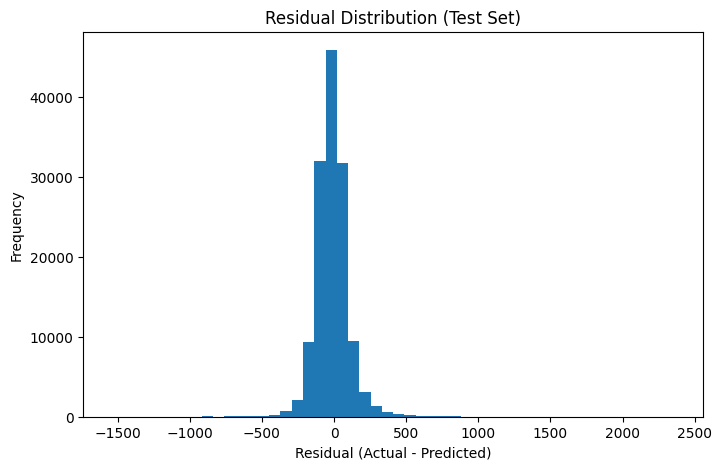

In [0]:
test_residuals = test_y - test_pred

plt.figure(figsize=(8,5))
plt.hist(test_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test Set)")
plt.show()

#### Residuals vs Predicted

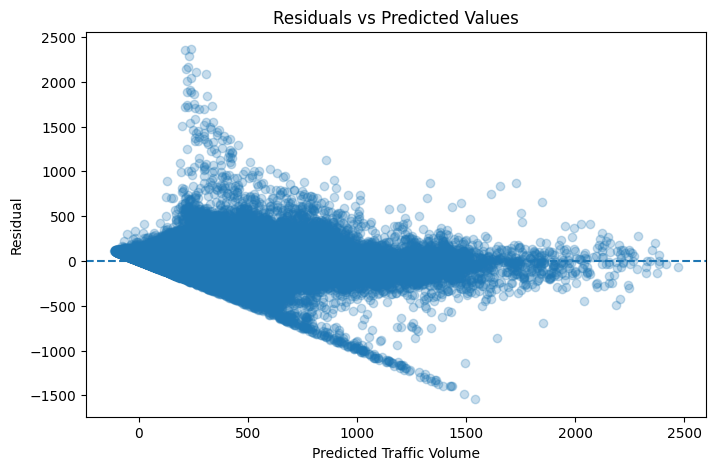

In [0]:
plt.figure(figsize=(8,5))
plt.scatter(test_pred, test_residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

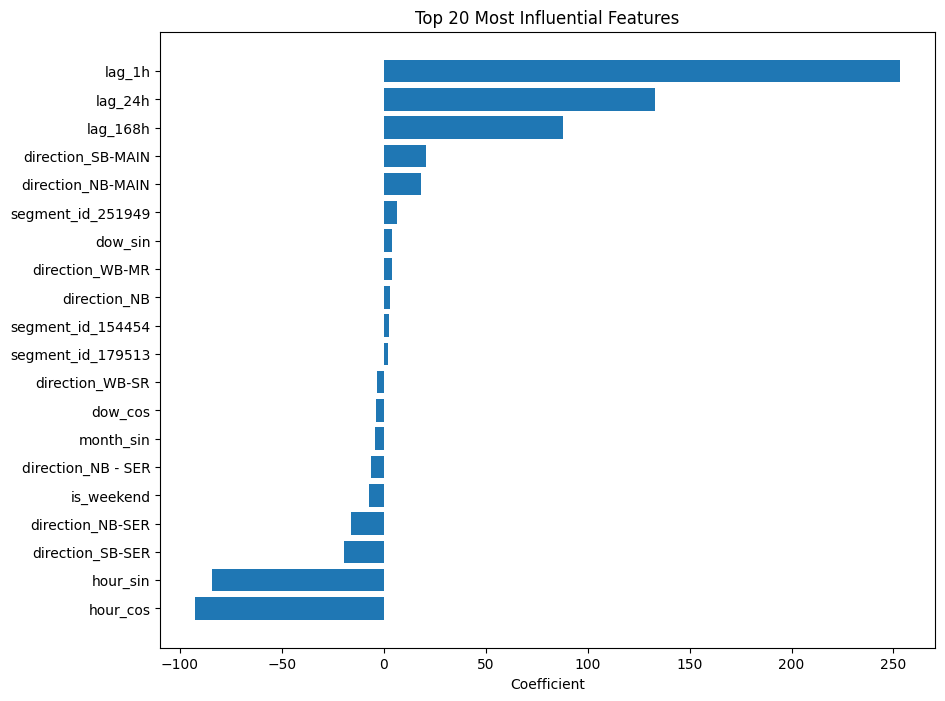

In [0]:
top_coef = coef_df.head(20).sort_values("coefficient")

plt.figure(figsize=(10,8))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 20 Most Influential Features")
plt.show()